In [1]:
# creating Markowitx Frontier between portfolio consisting 2 stocks - Nestle India and Nifty50

In [2]:

import yfinance as yf, pandas as pd, numpy as np, matplotlib.pyplot as plt

ticker = ['NESTLEIND.NS','^NSEI']

In [3]:
# taking data since 2021

raw_data = yf.download(ticker,start='2021-01-01',interval='5d')
df = pd.DataFrame(raw_data)['Close']
print(df)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed

Ticker      NESTLEIND.NS         ^NSEI
Date                                  
2021-01-05   1771.492188  14199.500000
2021-01-15   1702.358398  14433.700195
2021-01-20   1687.782349  14644.700195
2021-01-25   1662.386353  14238.900391
2021-02-04   1629.812134  14895.650391
...                  ...           ...
2025-03-20   2221.550049  23190.650391
2025-03-25   2254.850098  23668.650391
2025-04-04   2262.149902  22904.449219
2025-04-09   2344.850098  22399.150391
2025-04-17   2415.600098  23851.650391

[215 rows x 2 columns]


In [4]:
# calculating number of years

no_of_years = df.index.year.nunique() -1 

In [5]:
# CAGR of Nifty50 and Nestle

CAGR = (1 + df.iloc[-1]/df.iloc[0])**(1/no_of_years) - 1
print(CAGR)

Ticker
NESTLEIND.NS    0.239919
^NSEI           0.279451
dtype: float64


In [6]:
# Calculate annualized mean of natural log returns

log_return = np.log(df/df.shift(1))
log_return_mean = log_return.mean()*252
print(log_return_mean)

Ticker
NESTLEIND.NS    0.365195
^NSEI           0.610743
dtype: float64


In [7]:
# calcuating annualized covariance between 2 stocks

covariance = log_return.cov() * 252
print(covariance)

Ticker        NESTLEIND.NS     ^NSEI
Ticker                              
NESTLEIND.NS      0.146202  0.032273
^NSEI             0.032273  0.090503


In [8]:
# logic explaination
# step 1 - take 2 random number from standard normal distribution  
# step 2 - add these 2 numbers and divide both numbers with added number (now you have weights assigned)
# step 3 - multiply these weights with CAGR and sum it (this is portfolio return)
# step 4 - store this portfolio return in list
# step 5 - now calculate standard deviation of the portfolio based on weight and covariance ( after opening this formula - one will get (Weight of Asset 1)^2 * Variance of Asset 1 + (Weight of Asset 2)^2 * Variance of Asset 2 + 2 * Weight of Asset 1 * Weight of Asset 2 * Covariance between Asset 1 and Asset 2. )
# step 6 - store this portfilio std dev in list
# now repeat this step for large number of times(with different weight distribution among 2 stocks) 

In [9]:

ret = []
risk = []
for i in range(2000):
    weight = np.random.random(len(covariance.index))
    weight = weight/np.sum(weight) 
    r = np.sum(np.dot(weight,CAGR))
    ret.append(r)
    std_dev1 = np.dot(weight,np.dot(covariance,weight.T))**0.5  
    risk.append(std_dev1)

In [10]:
# respective risk and return for various weight distribution
print(risk,ret,sep='\n')

[np.float64(0.32317518124720446), np.float64(0.3592481472012324), np.float64(0.2678273513246615), np.float64(0.2883744839600013), np.float64(0.2925492178023375), np.float64(0.28309244898481456), np.float64(0.34962494134265293), np.float64(0.26997062812388234), np.float64(0.2954599072667004), np.float64(0.31469221568903044), np.float64(0.30719688406838663), np.float64(0.29249063072447723), np.float64(0.3277881073400082), np.float64(0.3446239222966528), np.float64(0.26751990862822217), np.float64(0.26881333533119545), np.float64(0.26739439531654047), np.float64(0.3065299424372122), np.float64(0.27761247770405506), np.float64(0.2675933164394307), np.float64(0.27527303446564727), np.float64(0.2661562565853065), np.float64(0.335941115599866), np.float64(0.29990981555092294), np.float64(0.2769655135291185), np.float64(0.26613824294404026), np.float64(0.28532348274237607), np.float64(0.2867510174104766), np.float64(0.3248121600439916), np.float64(0.27975851112970973), np.float64(0.28742550102

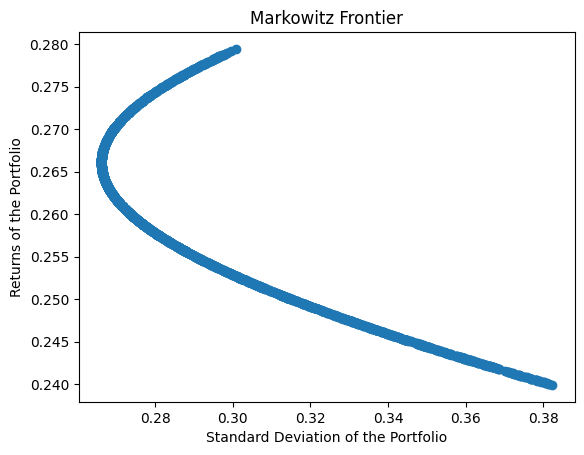

In [11]:
# plotting the Markowitz Frontier

plt.scatter(x= risk, y = ret)
plt.title("Markowitz Frontier")
plt.xlabel("Standard Deviation of the Portfolio")
plt.ylabel("Returns of the Portfolio")
plt.show()
